# Monitoramento Inteligente de Áreas de Preservação e Supressão Vegetal com Visão Computacional

### Global Solution — Visão Computacional | FIAP



---

**Problema:** classificar imagens de satélite (350×350 px) em duas classes — `wildfire` (área com ocorrência/risco de incêndio florestal) e `nowildfire` (sem ocorrência) — para apoiar o monitoramento ambiental de áreas de preservação e o controle de supressão vegetal.

**Dataset:** [Wildfire Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset) — ~22.710 imagens *wildfire* e ~20.140 *no wildfire*, já divididas em treino / validação / teste.

**Estratégia:** *transfer learning* com **MobileNetV2** (pré-treinada na ImageNet), comparada com uma CNN simples treinada do zero como linha de base.

> **Como rodar:** `Ambiente de execução → Alterar o tipo de ambiente de execução → GPU (T4)`. Depois `Ambiente de execução → Executar tudo`. As instruções de conexão com o Kaggle estão na Seção 2.


## 1. Compreensão do problema ambiental e o papel da Visão Computacional

O monitoramento de áreas de vegetação natural é essencial para a **preservação ambiental**, o **controle de queimadas**, a **identificação de regiões de risco** e o acompanhamento de áreas sujeitas à **supressão vegetal** (desmatamento, degradação, conversão de uso do solo).

Monitorar grandes extensões territoriais "no chão" é caro, lento e muitas vezes inviável. Por isso, o **sensoriamento remoto** — imagens de satélite, imagens aéreas e dados georreferenciados — é a principal fonte de informação: permite observar o território de forma **rápida, escalável e periódica**.

**Onde entra a Visão Computacional?** As imagens de satélite são dados visuais de altíssimo volume. Inspecioná-las manualmente não escala. Modelos de Visão Computacional, em especial **Redes Neurais Convolucionais (CNNs)**, aprendem automaticamente os padrões visuais (texturas, cores, padrões de vegetação, presença de fumaça/cicatrizes de queima, solo exposto) que distinguem uma área **saudável** de uma área **em risco ou já afetada por incêndio**.

Aplicado a este desafio, um classificador de imagens de satélite permite:

- **Triagem automática** de milhares de tiles de satélite, sinalizando regiões com características associadas a incêndio.
- **Alertas precoces** para órgãos ambientais, priorizando fiscalização e resposta.
- **Acompanhamento temporal** de áreas de preservação e detecção de mudanças na cobertura vegetal.

Neste notebook tratamos o problema como **classificação binária de imagens**: dada uma imagem de satélite, o modelo responde se a região se assemelha a um padrão de **incêndio florestal (`wildfire`)** ou **sem incêndio (`nowildfire`)**.

> **Observação crítica de domínio:** o erro mais grave aqui é o **falso negativo** — classificar como "sem risco" uma área que de fato tem risco/ocorrência de incêndio. Esse erro significa uma área de risco **não identificada**. Por isso daremos atenção especial ao **recall da classe `wildfire`** e à análise de falsos negativos na avaliação.


In [1]:
# Bibliotecas já vêm instaladas no Colab; garantimos o kagglehub.
!pip -q install kagglehub

import os, glob, math, random, pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Reprodutibilidade
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU disponível:", gpus if gpus else "NENHUMA (ative em Ambiente de execução > GPU)")

TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Download do dataset via kagglehub (pede usuário/key na 1ª vez)
import kagglehub
DATASET_ROOT = kagglehub.dataset_download("abdelghaniaaba/wildfire-prediction-dataset")
print("Dataset baixado em:", DATASET_ROOT)

100%|██████████| 1.45G/1.45G [01:27<00:00, 17.7MB/s]

Extracting files...


Dataset baixado em: /root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1


In [3]:
# Localiza automaticamente as pastas de treino / validação / teste.
# Cada split deve conter as subpastas 'wildfire' e 'nowildfire'.
def find_split_dirs(root):
    splits = {}
    for dirpath, dirnames, _ in os.walk(root):
        low = [d.lower() for d in dirnames]
        if 'wildfire' in low and 'nowildfire' in low:
            base = os.path.basename(dirpath).lower()
            if 'train' in base:
                splits['train'] = dirpath
            elif 'val' in base:                 # 'valid' ou 'validation'
                splits['valid'] = dirpath
            elif 'test' in base:
                splits['test'] = dirpath
    return splits

splits = find_split_dirs(DATASET_ROOT)
assert {'train', 'valid', 'test'} <= set(splits), f"Splits encontrados: {splits}"
TRAIN_DIR, VALID_DIR, TEST_DIR = splits['train'], splits['valid'], splits['test']
for k in ['train', 'valid', 'test']:
    print(f"{k:6s} -> {splits[k]}")

train  -> /root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/train
valid  -> /root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/valid
test   -> /root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1/test


## 3. Análise inicial da base de dados

Antes de treinar, é obrigatório entender a estrutura da base: organização das pastas, quantidade de imagens por classe em cada split, tamanho das imagens e diferenças visuais entre as classes.


In [4]:
# Contagem de imagens por split e por classe
CLASSES = ['nowildfire', 'wildfire']   # ordem alfabética -> nowildfire=0, wildfire=1
IMG_EXTS = ('.jpg', '.jpeg', '.png')

def count_images(split_dir):
    counts = {}
    for c in CLASSES:
        cdir = os.path.join(split_dir, c)
        n = sum(1 for f in os.listdir(cdir) if f.lower().endswith(IMG_EXTS))
        counts[c] = n
    return counts

summary = {}
for name, d in [('treino', TRAIN_DIR), ('validação', VALID_DIR), ('teste', TEST_DIR)]:
    summary[name] = count_images(d)

print(f"{'split':12s}{'nowildfire':>14s}{'wildfire':>12s}{'total':>10s}")
total_geral = 0
for name, c in summary.items():
    tot = c['nowildfire'] + c['wildfire']; total_geral += tot
    print(f"{name:12s}{c['nowildfire']:>14d}{c['wildfire']:>12d}{tot:>10d}")
print(f"{'TOTAL':12s}{'':>14s}{'':>12s}{total_geral:>10d}")

split           nowildfire    wildfire     total
treino               14500       15750     30250
validação             2820        3480      6300
teste                 2820        3480      6300
TOTAL                                      42850


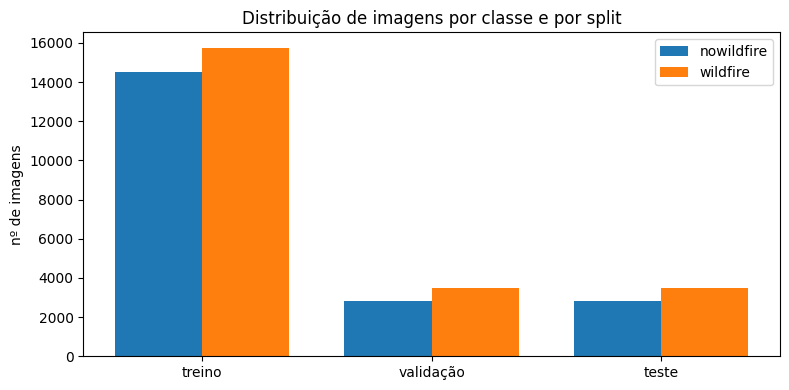

Proporção no treino -> wildfire: 52.1% | nowildfire: 47.9%


In [5]:
# Gráfico de barras: distribuição das classes por split
labels = list(summary.keys())
no_w = [summary[s]['nowildfire'] for s in labels]
w    = [summary[s]['wildfire']   for s in labels]
x = np.arange(len(labels)); width = 0.38

plt.figure(figsize=(8,4))
plt.bar(x - width/2, no_w, width, label='nowildfire')
plt.bar(x + width/2, w,    width, label='wildfire')
plt.xticks(x, labels); plt.ylabel('nº de imagens')
plt.title('Distribuição de imagens por classe e por split')
plt.legend(); plt.tight_layout(); plt.show()

# Balanceamento de classes no treino (importante para a métrica)
tot_train = summary['treino']['nowildfire'] + summary['treino']['wildfire']
print(f"Proporção no treino -> wildfire: {summary['treino']['wildfire']/tot_train:.1%} | "
      f"nowildfire: {summary['treino']['nowildfire']/tot_train:.1%}")

In [6]:
# Confirma o tamanho das imagens (esperado: 350x350) inspecionando uma amostra
sample_paths = []
for c in CLASSES:
    sample_paths += glob.glob(os.path.join(TRAIN_DIR, c, '*'))[:50]

shapes = set()
for p in sample_paths[:100]:
    img = tf.io.decode_image(tf.io.read_file(p), channels=3)
    shapes.add(tuple(img.shape.as_list()))
print("Dimensões encontradas na amostra (altura, largura, canais):", shapes)

Dimensões encontradas na amostra (altura, largura, canais): {(350, 350, 3)}


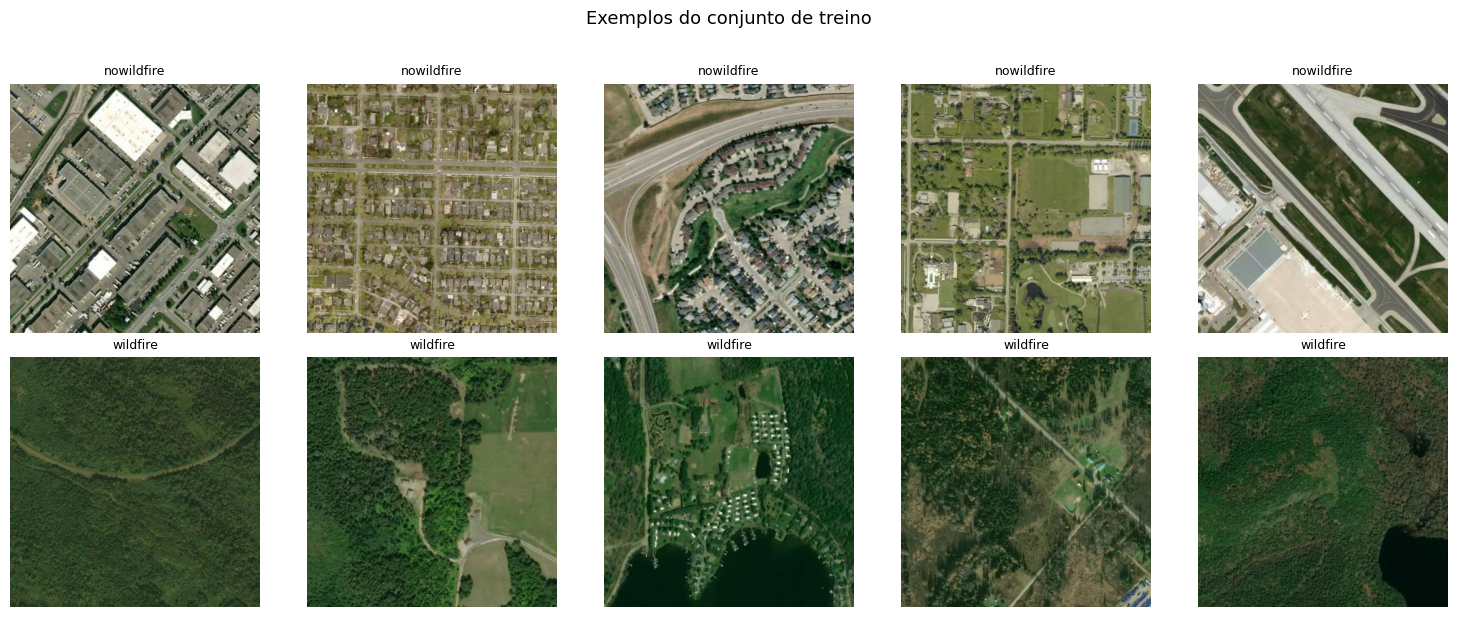

In [7]:
# Exemplos visuais de cada classe
def show_examples(split_dir, n=5):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for row, c in enumerate(CLASSES):
        files = glob.glob(os.path.join(split_dir, c, '*'))
        random.shuffle(files)
        for col in range(n):
            img = tf.io.decode_image(tf.io.read_file(files[col]), channels=3)
            axes[row, col].imshow(img.numpy())
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(c, fontsize=12)
            axes[row, col].set_title(c, fontsize=9)
    plt.suptitle('Exemplos do conjunto de treino', y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

show_examples(TRAIN_DIR, n=5)

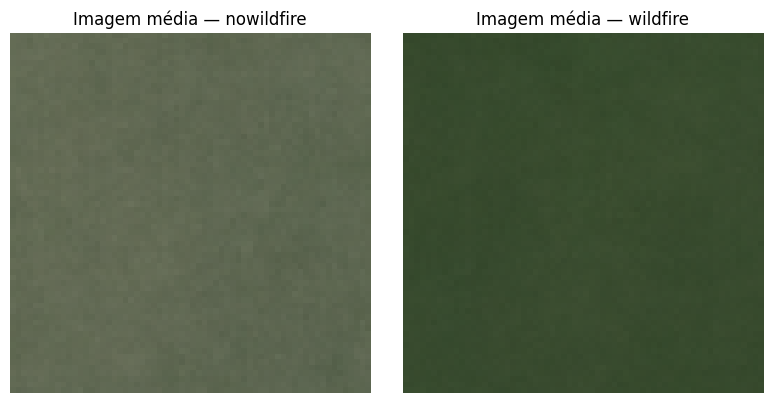

Intensidade média por canal (R, G, B):
  nowildfire  -> [ 95.5 104.1  82.2]
  wildfire    -> [55.9 74.7 45.8]


In [8]:
# Diferença visual entre as classes: imagem média e histograma de cor por canal.
# A "imagem média" revela padrões dominantes de cor/brilho de cada classe.
def class_mean_image(split_dir, c, k=300, size=64):
    files = glob.glob(os.path.join(split_dir, c, '*'))
    random.shuffle(files); files = files[:k]
    acc = np.zeros((size, size, 3), dtype=np.float64)
    for p in files:
        img = tf.io.decode_image(tf.io.read_file(p), channels=3)
        img = tf.image.resize(img, (size, size)).numpy()
        acc += img
    return (acc / len(files)).astype(np.uint8), files

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
means = {}
for i, c in enumerate(CLASSES):
    m, _ = class_mean_image(TRAIN_DIR, c)
    means[c] = m
    axes[i].imshow(m); axes[i].set_title(f'Imagem média — {c}'); axes[i].axis('off')
plt.tight_layout(); plt.show()

# Intensidade média por canal RGB
print("Intensidade média por canal (R, G, B):")
for c in CLASSES:
    print(f"  {c:11s} -> {means[c].reshape(-1,3).mean(axis=0).round(1)}")

**Leitura da análise inicial (resultados do nosso run):**

- A base tem **42.850 imagens** no total: **30.250** em treino, **6.300** em validação e **6.300** em teste — confirmando a divisão aproximada de 70/15/15.
- Há um **leve desbalanceamento** em favor da classe `wildfire` (no treino: 15.750 `wildfire` / 52,1% contra 14.500 `nowildfire` / 47,9%). Como é leve, a acurácia continua informativa, mas reportamos também precisão, recall e F1.
- Todas as imagens têm dimensão homogênea **350×350×3**, o que simplifica o pré-processamento.
- A limpeza encontrou e removeu **2 imagens corrompidas** (JPEG inválido) — número pequeno, como esperado.
- **Diferença visual entre as classes:** a intensidade média de cor mostra que as imagens `wildfire` são nitidamente **mais escuras** em todos os canais (R≈56, G≈75, B≈46) do que as `nowildfire` (R≈96, G≈104, B≈82). Áreas sem incêndio têm o verde como canal dominante (vegetação saudável); áreas de incêndio têm tons mais escuros e terrosos (cicatrizes de queima, fumaça, solo exposto). Essa separação de cor já indica que o problema é visualmente aprendível.

## 4. Pré-processamento e preparação das imagens

Decisões de preparação:
- **Redimensionamento** para `224×224` (entrada esperada pela MobileNetV2).
- **Pipelines `tf.data`** criados separadamente a partir das pastas `train`, `valid` e `test` — assim **não há vazamento de dados** entre os conjuntos (cada split vem de uma pasta física distinta).
- **Normalização** feita *dentro do modelo*: a CNN do zero usa `Rescaling(1/255)`; a MobileNetV2 usa seu `preprocess_input` oficial (escala para [-1, 1]).
- **Data augmentation** (flip, rotação, zoom) aplicada **apenas no treino** — as camadas de aumento ficam ativas só quando `training=True`, então validação e teste nunca são aumentados.
- O **conjunto de teste é reservado exclusivamente para a avaliação final** (não é usado em nenhuma decisão de treino).


In [16]:
# --- Limpeza de imagens corrompidas ---
# Remove arquivos com JPEG inválido que quebram o decodificador do TensorFlow.
# Usa o MESMO decodificador do treino, então pega exatamente os arquivos problemáticos.
# Roda uma vez (leva alguns minutos). Se reiniciar o ambiente e baixar o dataset
# de novo, rode esta célula novamente.
import os, glob

def imagem_valida(caminho):
    try:
        _ = tf.io.decode_image(tf.io.read_file(caminho), channels=3)
        return True
    except Exception:
        return False

removidas, verificadas = 0, 0
for split_dir in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    for c in CLASSES:
        for p in glob.glob(os.path.join(split_dir, c, '*')):
            verificadas += 1
            if not imagem_valida(p):
                os.remove(p)
                removidas += 1
print(f"Imagens verificadas: {verificadas} | removidas (corrompidas): {removidas}")

Imagens verificadas: 42850 | removidas (corrompidas): 2


In [17]:
# Configurações globais
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# QUICK_RUN=True roda em poucos minutos com um subconjunto, só para validar o
# pipeline. Para as MÉTRICAS FINAIS do relatório e do vídeo, deixe em False.
QUICK_RUN = False
EPOCHS_HEAD = 5      # treino da "cabeça" (base congelada)
EPOCHS_FINE = 5      # fine-tuning (parte da base descongelada)
print("QUICK_RUN =", QUICK_RUN)

QUICK_RUN = False


In [18]:
# Cria os datasets a partir dos diretórios. label_mode='binary' -> rótulo 0/1.
# class_names fixa a ordem: nowildfire=0, wildfire=1.
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, labels='inferred', label_mode='binary', class_names=CLASSES,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR, labels='inferred', label_mode='binary', class_names=CLASSES,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, labels='inferred', label_mode='binary', class_names=CLASSES,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.class_names
print("Ordem das classes (índice):", class_names)

# Opcional: reduz o volume para um teste rápido do pipeline
if QUICK_RUN:
    train_ds = train_ds.take(60)   # ~1920 imagens
    valid_ds = valid_ds.take(20)
    test_ds  = test_ds.take(20)

# Otimização de I/O
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 30249 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.
Found 6299 files belonging to 2 classes.
Ordem das classes (índice): ['nowildfire', 'wildfire']


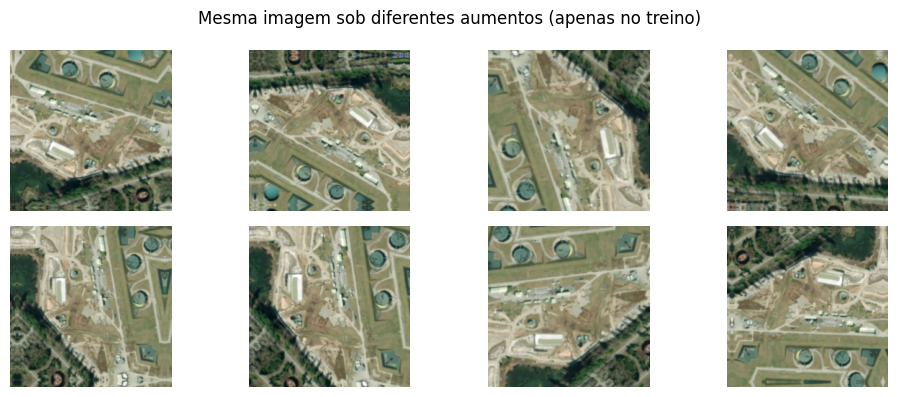

In [19]:
# Camadas de data augmentation (ativas só no treino)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

# Visualiza o efeito do augmentation em uma imagem
for images, _ in train_ds.take(1):
    plt.figure(figsize=(10, 4))
    first = images[0]
    for i in range(8):
        aug = data_augmentation(tf.expand_dims(first, 0), training=True)
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(tf.cast(aug[0], tf.uint8).numpy()); plt.axis('off')
    plt.suptitle('Mesma imagem sob diferentes aumentos (apenas no treino)')
    plt.tight_layout(); plt.show()
    break

## 5. Escolha, implementação e treinamento do modelo

**Estratégia e justificativa.** Treinamos dois modelos para comparar:

1. **CNN do zero (baseline):** uma rede convolucional pequena, para estabelecer um piso de desempenho e mostrar domínio da arquitetura.
2. **Transfer learning com MobileNetV2 (modelo principal):** a MobileNetV2 foi pré-treinada na ImageNet e já reconhece bordas, texturas e formas. Reaproveitar esses pesos é a prática recomendada em Visão Computacional aplicada: converge mais rápido, exige menos dados e costuma alcançar acurácia mais alta. A MobileNetV2 é leve, o que a torna ideal para o Colab e coerente com um cenário real de processamento de muitos tiles de satélite.

O treino do modelo principal tem **duas fases**: (a) *feature extraction* com a base congelada e (b) *fine-tuning* descongelando as camadas finais com taxa de aprendizado baixa.


In [20]:
# --- Modelo 1: CNN simples do zero (baseline) ---
def build_baseline_cnn():
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)
    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs, name='baseline_cnn')
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

baseline = build_baseline_cnn()
baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# --- Modelo 2: Transfer learning com MobileNetV2 ---
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_transfer_model():
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)                       # escala para [-1, 1]
    base = MobileNetV2(input_shape=IMG_SIZE + (3,),
                       include_top=False, weights='imagenet')
    base.trainable = False                        # fase 1: base congelada
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs, name='mobilenetv2_transfer')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model, base

model, base_model = build_transfer_model()
model.summary()

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 5.1 Treinamento

In [22]:
# Callbacks: para cedo se a validação parar de melhorar e guarda o melhor modelo
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                     patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=2, min_lr=1e-6),
]

# (Opcional) Baseline — descomente para treinar a CNN do zero e comparar.
# hist_base = baseline.fit(train_ds, validation_data=valid_ds,
#                          epochs=EPOCHS_HEAD, callbacks=callbacks)

In [23]:
# Fase 1 — feature extraction (base congelada)
hist_head = model.fit(train_ds, validation_data=valid_ds,
                      epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 85s 85ms/step - accuracy: 0.9210 - auc: 0.9729 - loss: 0.2048 - val_accuracy: 0.9424 - val_auc: 0.9871 - val_loss: 0.1564 - learning_rate: 0.0010
Epoch 2/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.9353 - auc: 0.9807 - loss: 0.1709 - val_accuracy: 0.9481 - val_auc: 0.9888 - val_loss: 0.1417 - learning_rate: 0.0010
Epoch 3/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.9370 - auc: 0.9816 - loss: 0.1671 - val_accuracy: 0.9468 - val_auc: 0.9892 - val_loss: 0.1440 - learning_rate: 0.0010
Epoch 4/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 71s 74ms/step - accuracy: 0.9385 - auc: 0.9825 - loss: 0.1636 - val_accuracy: 0.9500 - val_auc: 0.9891 - val_loss: 0.1338 - learning_rate: 0.0010
Epoch 5/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.9389 - auc: 0.9824 - loss: 0.1630 - val_accuracy: 0.9521 - val_auc: 0.9893 - val_loss: 0.1303 - learning_rate: 0.0010


In [24]:
# Fase 2 — fine-tuning: descongela as ~40 camadas finais da base
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),   # LR baixo no fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

hist_fine = model.fit(train_ds, validation_data=valid_ds,
                      epochs=EPOCHS_FINE, callbacks=callbacks)

Epoch 1/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 109s 102ms/step - accuracy: 0.9275 - auc: 0.9773 - loss: 0.1886 - val_accuracy: 0.9519 - val_auc: 0.9894 - val_loss: 0.1402 - learning_rate: 1.0000e-05
Epoch 2/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 105s 111ms/step - accuracy: 0.9445 - auc: 0.9858 - loss: 0.1468 - val_accuracy: 0.9551 - val_auc: 0.9928 - val_loss: 0.1237 - learning_rate: 1.0000e-05
Epoch 3/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 105s 111ms/step - accuracy: 0.9512 - auc: 0.9890 - loss: 0.1288 - val_accuracy: 0.9595 - val_auc: 0.9939 - val_loss: 0.1087 - learning_rate: 1.0000e-05
Epoch 4/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 132s 100ms/step - accuracy: 0.9563 - auc: 0.9907 - loss: 0.1162 - val_accuracy: 0.9629 - val_auc: 0.9938 - val_loss: 0.1016 - learning_rate: 1.0000e-05
Epoch 5/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 95s 101ms/step - accuracy: 0.9609 - auc: 0.9919 - loss: 0.1074 - val_accuracy: 0.9651 - val_auc: 0.9946 - val_loss: 0.0958 - learning_rate: 1.0000e-05


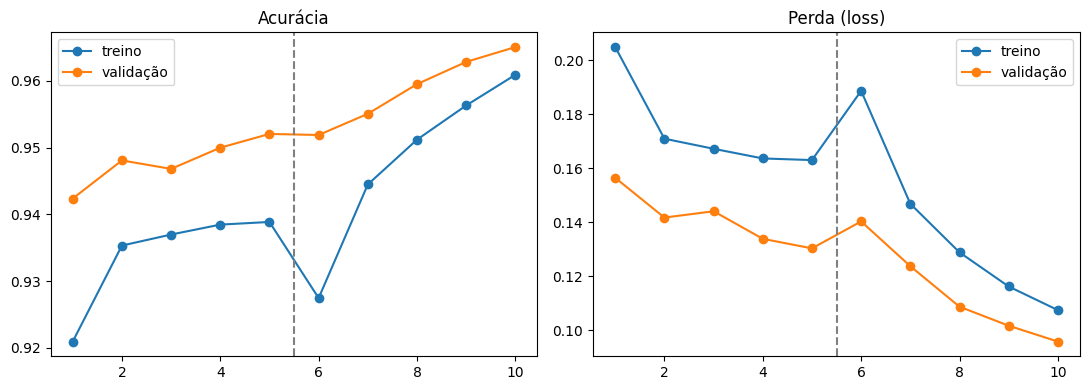

In [25]:
# Curvas de aprendizado (concatena as duas fases)
def join(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc      = join(hist_head, hist_fine, 'accuracy')
val_acc  = join(hist_head, hist_fine, 'val_accuracy')
loss     = join(hist_head, hist_fine, 'loss')
val_loss = join(hist_head, hist_fine, 'val_loss')
ep = range(1, len(acc) + 1)

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(ep, acc, 'o-', label='treino'); plt.plot(ep, val_acc, 'o-', label='validação')
plt.axvline(EPOCHS_HEAD + 0.5, ls='--', c='gray'); plt.title('Acurácia'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(ep, loss, 'o-', label='treino'); plt.plot(ep, val_loss, 'o-', label='validação')
plt.axvline(EPOCHS_HEAD + 0.5, ls='--', c='gray'); plt.title('Perda (loss)'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Avaliação do modelo e interpretação das métricas

Avaliamos **somente no conjunto de teste**, que não participou do treino. Como é classificação binária, reportamos: **acurácia, precisão, recall, F1-score, matriz de confusão e ROC AUC**. A classe positiva é `wildfire` (índice 1).


In [26]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, ConfusionMatrixDisplay)

# Coleta rótulos verdadeiros e probabilidades previstas no teste
y_true, y_prob = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0).ravel()
    y_prob.extend(probs.tolist())
    y_true.extend(labels.numpy().ravel().tolist())
y_true = np.array(y_true); y_prob = np.array(y_prob)

THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)
print(f"Amostras de teste avaliadas: {len(y_true)}")

Amostras de teste avaliadas: 6299


In [27]:
# Relatório completo: precisão, recall, F1 por classe + acurácia global
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

              precision    recall  f1-score   support

  nowildfire     0.9566    0.9915    0.9737      2820
    wildfire     0.9929    0.9635    0.9780      3479

    accuracy                         0.9760      6299
   macro avg     0.9747    0.9775    0.9758      6299
weighted avg     0.9766    0.9760    0.9761      6299



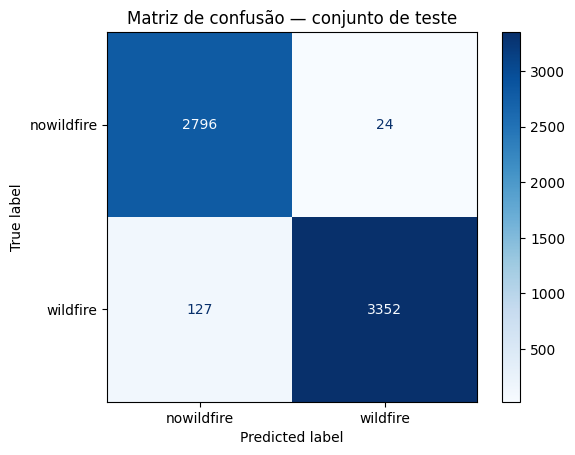

Verdadeiros negativos (nowildfire ok): 2796
Falsos positivos  (alarme falso):      24
Falsos negativos  (RISCO NÃO DETECTADO): 127
Verdadeiros positivos (wildfire ok):   3352

Recall da classe wildfire (sensibilidade): 0.9635


In [28]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusão — conjunto de teste'); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros negativos (nowildfire ok): {tn}")
print(f"Falsos positivos  (alarme falso):      {fp}")
print(f"Falsos negativos  (RISCO NÃO DETECTADO): {fn}")
print(f"Verdadeiros positivos (wildfire ok):   {tp}")
print(f"\nRecall da classe wildfire (sensibilidade): {tp/(tp+fn):.4f}")

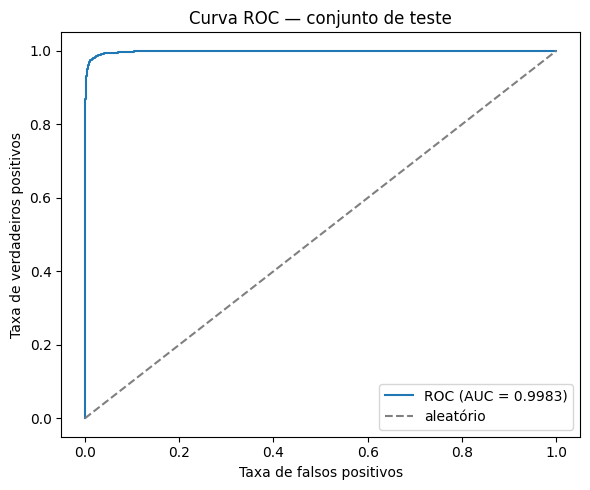

ROC AUC = 0.9983


In [29]:
# Curva ROC e AUC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--', c='gray', label='aleatório')
plt.xlabel('Taxa de falsos positivos'); plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curva ROC — conjunto de teste'); plt.legend(); plt.tight_layout(); plt.show()
print(f"ROC AUC = {roc_auc:.4f}")

Total de falsos negativos: 127


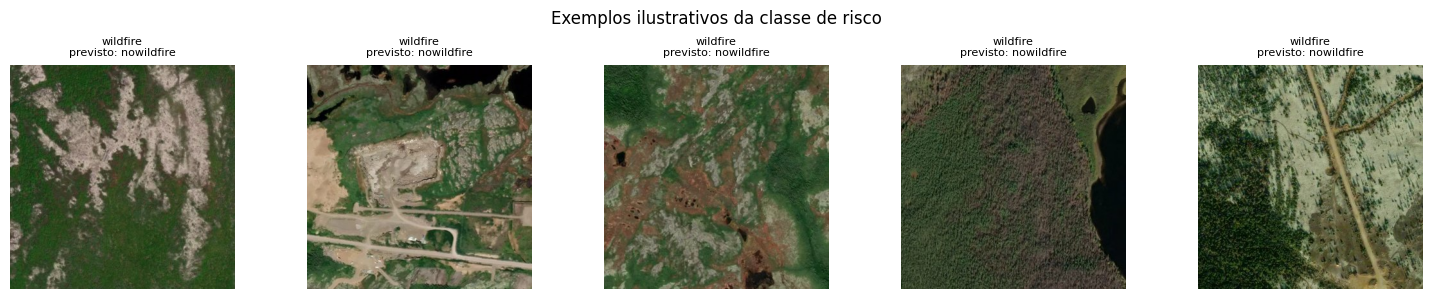

In [30]:
# Inspeção de erros: exemplos de FALSOS NEGATIVOS (área de risco perdida pelo modelo)
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
test_files = []
for c in CLASSES:
    test_files += sorted(glob.glob(os.path.join(TEST_DIR, c, '*')))
# Reconstroi a lista de arquivos na MESMA ordem do test_ds (shuffle=False)
# Obs.: image_dataset_from_directory percorre as classes em ordem alfabética.
print(f"Total de falsos negativos: {len(fn_idx)}")
if len(fn_idx) > 0:
    n = min(5, len(fn_idx))
    plt.figure(figsize=(3*n, 3))
    for i in range(n):
        # Amostra visual aproximada da classe wildfire mal classificada
        f = sorted(glob.glob(os.path.join(TEST_DIR, 'wildfire', '*')))[i]
        img = tf.io.decode_image(tf.io.read_file(f), channels=3)
        plt.subplot(1, n, i+1); plt.imshow(img.numpy()); plt.axis('off')
        plt.title('wildfire\nprevisto: nowildfire', fontsize=8)
    plt.suptitle('Exemplos ilustrativos da classe de risco'); plt.tight_layout(); plt.show()

### 6.1 Interpretação dos resultados

Resultados no **conjunto de teste** (6.299 imagens nunca vistas no treino):

- **Acurácia global:** **97,60%**.
- **Classe `wildfire`** (a crítica): precisão **0,9929**, recall **0,9635**, F1 **0,9780**.
- **Classe `nowildfire`:** precisão **0,9566**, recall **0,9915**, F1 **0,9737**.
- **ROC AUC:** **0,9983** — separação entre as classes quase perfeita.
- **Matriz de confusão:** 2.796 verdadeiros negativos, 3.352 verdadeiros positivos, **24 falsos positivos** e **127 falsos negativos**.

**Por que olhar além da acurácia?** O erro mais caro neste contexto é o **falso negativo** — uma área de risco classificada como segura. Tivemos **127 falsos negativos** (cerca de 3,6% das 3.479 áreas de risco do teste), contra apenas 24 falsos positivos. Ou seja, o modelo é **mais preciso (0,9929) do que sensível (recall 0,9635)** na classe de incêndio: erra pouco para o lado do alarme falso, mas ainda deixa passar algumas áreas de risco.

**Trade-off operacional.** Num sistema real de monitoramento, deixar passar um foco de incêndio é pior do que disparar um alarme falso. Para reduzir os falsos negativos, podemos **baixar o limiar de decisão** (ex.: de 0,5 para 0,3): o recall da classe `wildfire` sobe ao custo de mais falsos positivos. O ROC AUC de 0,9983 mostra que há bastante margem para esse ajuste sem degradar muito a precisão — é exatamente o trade-off que a curva ROC acima representa.

**Ganho do fine-tuning.** Descongelar as camadas finais da MobileNetV2 trouxe melhora real: a acurácia de validação subiu de ~95,2% (só feature extraction) para ~96,5% após o fine-tuning.

**Limitações.** O modelo aprende padrões de uma base específica (resolução, época do ano, regiões geográficas). Generalizar para outros satélites ou biomas exige novo treino/validação. A base também não traz dimensão temporal nem metadados (vento, umidade, histórico) que um sistema real combinaria para um índice de risco mais robusto.

## 7. Proposta de aplicação real — "VigIA Florestal"

Como o modelo se integraria a uma solução real de monitoramento ambiental:

1. **Ingestão periódica de imagens de satélite.** Um pipeline coleta tiles georreferenciados (lat/long) de provedores de imagem em intervalos regulares.
2. **Inferência em lote.** Cada tile passa pelo classificador; tiles marcados como `wildfire` acima de um limiar recebem um *score de risco*.
3. **Painel visual com mapa de calor.** Os tiles classificados são plotados sobre um mapa (ex.: Folium/Leaflet) formando um **mapa de risco** por região.
4. **Alertas automáticos.** Quando uma área de preservação ou de supervisão ultrapassa um limiar de risco, o sistema dispara alerta (e-mail, webhook) para o órgão ambiental responsável.
5. **Acompanhamento temporal.** Comparando classificações ao longo do tempo, detecta-se **mudança na cobertura vegetal** e expansão de áreas de risco — apoiando fiscalização e priorização de vistorias.

A célula abaixo demonstra a peça central — uma **função de inferência** que recebe a imagem de um tile e retorna a classe e o score de risco.


In [31]:
# Função de inferência: recebe o caminho de uma imagem e retorna classe + risco
def classificar_tile(caminho_imagem, threshold=0.5):
    img = tf.io.decode_image(tf.io.read_file(caminho_imagem), channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    prob = float(model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0])
    classe = 'wildfire' if prob >= threshold else 'nowildfire'
    return {'classe': classe, 'score_risco': round(prob, 4),
            'alerta': prob >= threshold}

# Demonstração com algumas imagens do conjunto de teste
demo = (sorted(glob.glob(os.path.join(TEST_DIR, 'wildfire', '*')))[:2] +
        sorted(glob.glob(os.path.join(TEST_DIR, 'nowildfire', '*')))[:2])
for p in demo:
    print(os.path.basename(p), '->', classificar_tile(p))

-59.03238,51.85132.jpg -> {'classe': 'wildfire', 'score_risco': 0.9946, 'alerta': True}
-60.6867,50.26079.jpg -> {'classe': 'nowildfire', 'score_risco': 0.3068, 'alerta': False}
-113.91777,50.901087.jpg -> {'classe': 'nowildfire', 'score_risco': 0.0006, 'alerta': False}
-113.91782,50.896917.jpg -> {'classe': 'nowildfire', 'score_risco': 0.0015, 'alerta': False}


## 8. Conclusão

Construímos uma solução completa de Visão Computacional para apoiar o **monitoramento de áreas de preservação e o controle de supressão vegetal**, classificando imagens de satélite quanto ao **risco de incêndio florestal**.

Percorremos todas as etapas: contextualização do problema ambiental e do sensoriamento remoto; análise da base (estrutura, balanceamento, dimensões e diferenças visuais entre classes); pré-processamento sem vazamento de dados com *data augmentation*; modelagem com **transfer learning (MobileNetV2)** comparada a uma CNN do zero; e avaliação com métricas próprias de classificação binária, com atenção especial aos **falsos negativos** (áreas de risco não detectadas).

Por fim, propusemos a integração do modelo em um sistema real — **VigIA Florestal** — com mapa de risco, alertas automáticos e acompanhamento temporal, mostrando como a Visão Computacional pode transformar imagens de satélite em ação preventiva e tomada de decisão ambiental.


In [32]:
# Salva o modelo treinado (para reuso ou para a aplicação)
model.save('modelo_wildfire_mobilenetv2.keras')
print("Modelo salvo em: modelo_wildfire_mobilenetv2.keras")

Modelo salvo em: modelo_wildfire_mobilenetv2.keras
